# NumCompute Quickstart Demo

This notebook demonstrates the NumCompute package end-to-end using only Python and NumPy.

## 1. Imports

In [1]:
import os
os.remove('iris.csv')
import sys
import numpy as np

# Allow notebook to import local package from project root
sys.path.append(os.path.abspath('..'))

import numpy as np
from numcompute_stream.io import read_csv
from numcompute_stream.preprocessing import StandardScaler
from numcompute_stream.tree import DecisionTreeClassifier
from numcompute_stream.ensemble import RandomForestClassifier
from numcompute_stream.pipeline import Pipeline
from numcompute_stream.metrics import StreamingMetrics
from numcompute_stream.stream import StreamTrainer
from numcompute_stream.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth
)

## 2. Choose iris datasets
### 2.1 Download iris datasets as 'iris.csv'

In [2]:
import urllib.request
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

# download if not already there
if not os.path.exists('iris.csv'):
    urllib.request.urlretrieve(url, 'iris.csv')
    print("downloaded iris.csv")
else:
    print("iris.csv already exists")

downloaded iris.csv


### 2.2 Decode header as 0 - Iris-setosa, 1 - Iris-versicolor, 2 - Iris-virginica

In [3]:
with open('iris.csv', 'r') as f:
    lines = f.readlines()

# only rewrite if the first line is not a header
if not lines[0].startswith('sepal_length'):
    # convert string labels to numbers
    content = "".join(lines)
    content = content.replace('Iris-setosa', '0')
    content = content.replace('Iris-versicolor', '1')
    content = content.replace('Iris-virginica', '2')

    with open('iris.csv', 'w') as f:
        f.write('sepal_length,sepal_width,petal_length,petal_width,label\n')
        f.write(content)

print("iris.csv ready")

iris.csv ready


## 3.Load datasets

In [4]:
chunks = list(read_csv('iris.csv', chunk_size=30, return_dict=False))
print(f"Total chunks: {len(chunks)}")
print(f"Chunk shape: {chunks[0].shape}")

Total chunks: 6
Chunk shape: (30, 5)


## 4. Set up two pipelines

In [5]:
# single decision tree pipeline
tree_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', DecisionTreeClassifier(max_depth=5))
])

# random forest pipeline
rf_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=10, max_depth=5))
])

tree_metrics = StreamingMetrics()
rf_metrics = StreamingMetrics()

tree_trainer = StreamTrainer(tree_pipe, tree_metrics)
rf_trainer = StreamTrainer(rf_pipe, rf_metrics)

## 5. Stream Traning Loop

In [6]:
tree_accuracies = []
rf_accuracies = []

for chunk in chunks:
    X_chunk = chunk[:, :-1]
    y_chunk = chunk[:, -1].astype(int)
    
    # fit and score both models
    tree_trainer.fit_chunk(X_chunk, y_chunk)
    rf_trainer.fit_chunk(X_chunk, y_chunk)
    
    tree_results = tree_trainer.score_chunk(X_chunk, y_chunk)
    rf_results = rf_trainer.score_chunk(X_chunk, y_chunk)
    
    tree_accuracies.append(tree_results['accuracy'])
    rf_accuracies.append(rf_results['accuracy'])

print("Training complete.")
print(f"Final tree accuracy: {tree_accuracies[-1]:.3f}")
print(f"Final RF accuracy: {rf_accuracies[-1]:.3f}")

Training complete.
Final tree accuracy: 0.980
Final RF accuracy: 0.894


/var/folders/v3/6wrfqwd54x1dvfzmk37f_1bw0000gn/T/ipykernel_28039/156644574.py:6: RuntimeWarning: invalid value encountered in cast
  y_chunk = chunk[:, -1].astype(int)
/Users/thanhlich/Downloads/Numcompute-1/numcompute_stream/preprocessing.py:49: RuntimeWarning: Mean of empty slice
  chunk_mean = np.nanmean(X, axis=0)
/Users/thanhlich/Downloads/Numcompute-1/numcompute_stream/preprocessing.py:50: RuntimeWarning: Degrees of freedom <= 0 for slice.
  chunk_var = np.nanvar(X, axis=0)


## 6. Visualise Metric

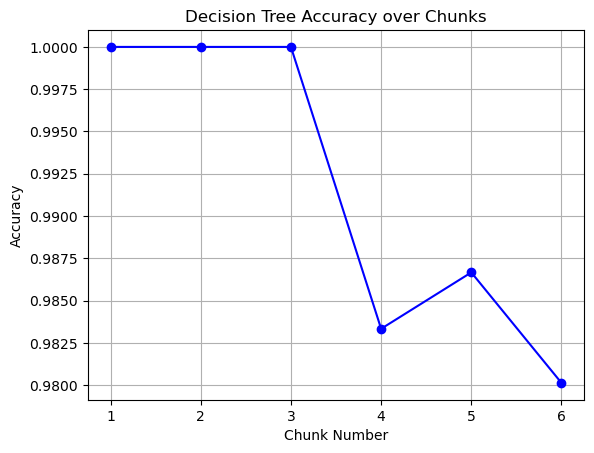

In [7]:
plot_metric_over_time(
    tree_accuracies,
    title='Decision Tree Accuracy over Chunks',
    ylabel='Accuracy'
)

## 7. Compare models

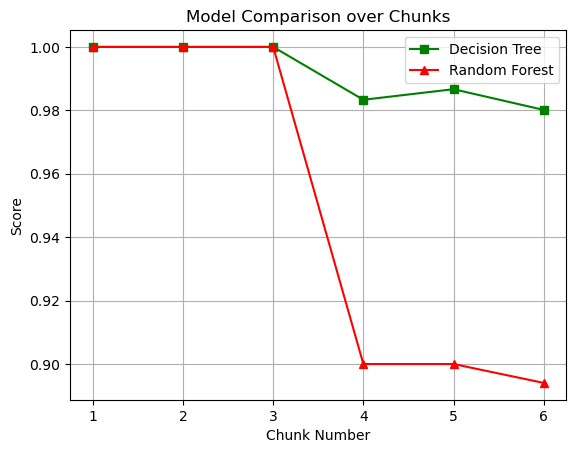

In [8]:
compare_models(
    tree_accuracies,
    rf_accuracies,
    labels=['Decision Tree', 'Random Forest'],
    title='Model Comparison over Chunks'
)

## 8. Predictions VS Ground Truth

/var/folders/v3/6wrfqwd54x1dvfzmk37f_1bw0000gn/T/ipykernel_28039/822895964.py:3: RuntimeWarning: invalid value encountered in cast
  y_last = last_chunk[:, -1].astype(int)


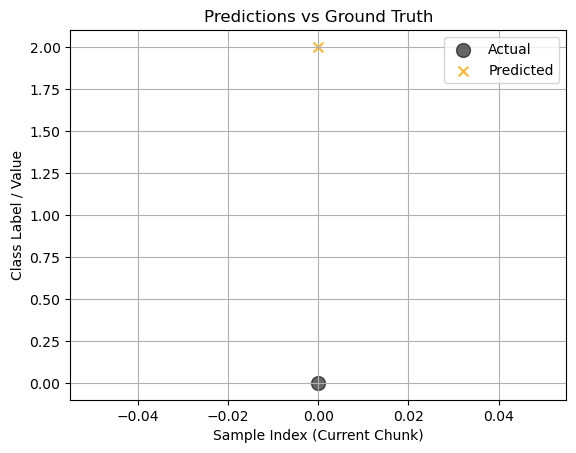

In [9]:
last_chunk = chunks[-1]
X_last = last_chunk[:, :-1]
y_last = last_chunk[:, -1].astype(int)

y_pred = rf_pipe.predict(X_last)

plot_predictions_vs_ground_truth(y_last, y_pred)

## 9. Show logs

In [10]:
log = tree_trainer.get_log()
print(f"Total log entries: {len(log)}")
for entry in log[:5]:
    print(entry)

Total log entries: 12
{'chunk': 1, 'type': 'fit', 'memory_footprint': 0.0001220703125}
{'chunk': 1, 'type': 'score', 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'memory_footprint': 0.0001220703125}
{'chunk': 2, 'type': 'fit', 'memory_footprint': 0.0001220703125}
{'chunk': 2, 'type': 'score', 'chunk_accuracy': 1.0, 'cumulative_accuracy': 1.0, 'memory_footprint': 0.0001220703125}
{'chunk': 3, 'type': 'fit', 'memory_footprint': 0.0001220703125}
